# 05 ResNet50 Multi-Class Classification

This notebook trains and evaluates a ResNet50 transfer learning model for four-class visual sentiment classification. It represents the strongest multi-class model in the report.

> **Note:** File paths are written for Google Colab. Update dataset/model paths before running in a new environment.

##1. Import libraries

In [ ]:
!pip install tensorflow

In [ ]:
!pip install -q split-folders

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import splitfolders
import seaborn as sns

from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix

##2. Set dataset path and hyperparameters

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sargisiskandaryan/unsplash-images")

print("Path to dataset files:", path)

100%|██████████| 6.67G/6.67G [00:56<00:00, 127MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sargisiskandaryan/unsplash-images/versions/2


In [ ]:
# Set random seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Dataset paths
input_folder = path
output_folder = "/content/sentiment_data_split"

# Image and training hyperparameters
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
NUM_CLASSES = 4

INITIAL_EPOCHS = 10
FINE_TUNE_EPOCHS = 10

INITIAL_LR = 1e-4
FINE_TUNE_LR = 1e-5

# Remove old split folder before re-splitting
if os.path.exists(output_folder):
    import shutil
    shutil.rmtree(output_folder)
    print(f"Removed old folder: {output_folder}")

##3. Split and Load dataset

In [ ]:
# Check original class distribution
print("Original dataset distribution:")
for cls in os.listdir(input_folder):
    cls_path = os.path.join(input_folder, cls)
    if os.path.isdir(cls_path):
        print(f"{cls}: {len(os.listdir(cls_path))} images")
# Split dataset into train / val / test = 70 / 15 / 15
splitfolders.ratio(
    input_folder,
    output=output_folder,
    seed=SEED,
    ratio=(0.7, 0.15, 0.15)
)
print("Data split completed.")

train_dir = os.path.join(output_folder, "train")
val_dir = os.path.join(output_folder, "val")
test_dir = os.path.join(output_folder, "test")

Original dataset distribution:
happy: 238 images
sad: 240 images
angry: 240 images
melancholic: 186 images


Copying files: 904 files [00:39, 22.88 files/s]

Data split completed.


In [ ]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    shuffle=True,
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    shuffle=False,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    shuffle=False,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

Found 632 files belonging to 4 classes.
Found 134 files belonging to 4 classes.
Found 138 files belonging to 4 classes.


In [ ]:
class_names = train_dataset.class_names
print("Class names:", class_names)

Class names: ['angry', 'happy', 'melancholic', 'sad']


##4. Visualize samples

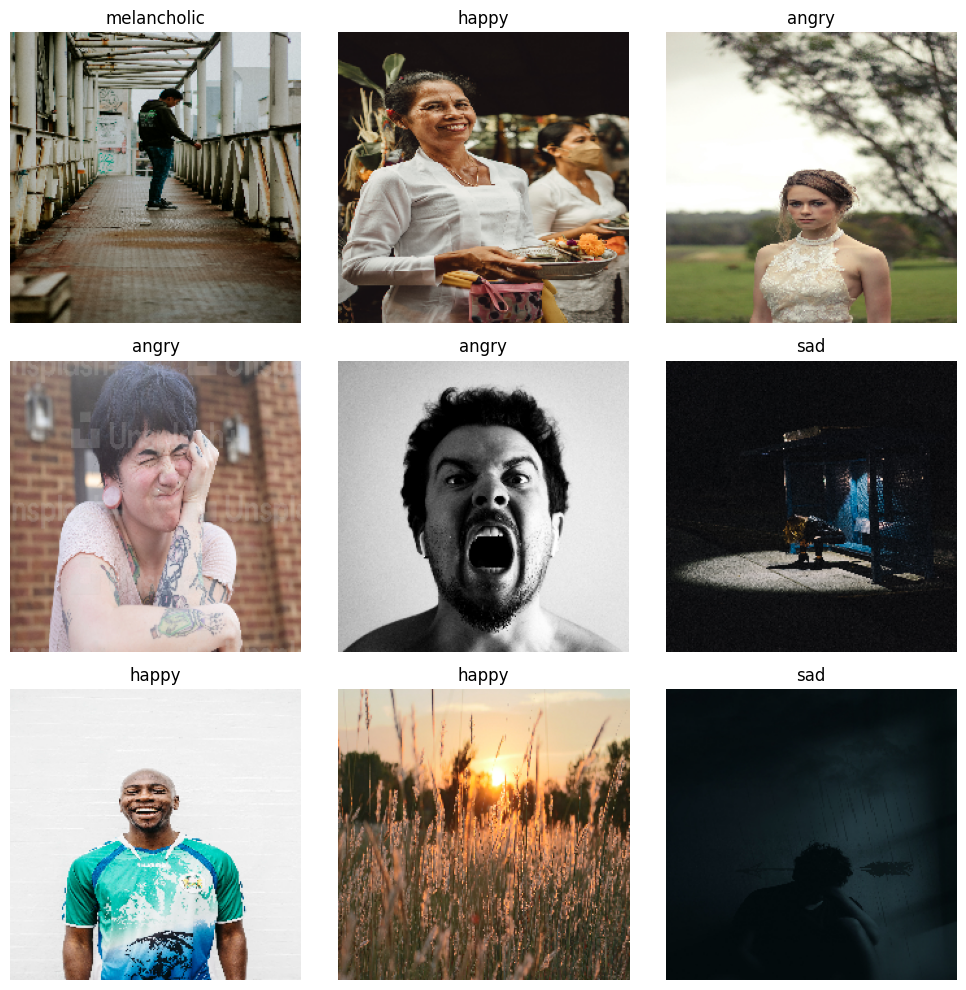

In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.tight_layout()
plt.show()

##5. Data preprocessing and data augmentation

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
], name="data_augmentation")

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

##6. Load pretrained ResNet base model

In [ ]:
base_model = ResNet50(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False
print("Base model loaded. Trainable:", base_model.trainable)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Base model loaded. Trainable: False


##7. Build the transfer learning model

In [ ]:
inputs = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))

x = data_augmentation(inputs)
x = preprocess_input(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=INITIAL_LR),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ data_augmentatio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4)         │      8,196 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,595,908 (90.01 MB)

 Trainable params: 8,196 (32.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

##8. Train the classifier head with frozen base

In [ ]:
history = model.fit(
    train_dataset,
    epochs=INITIAL_EPOCHS,
    validation_data=validation_dataset
)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 164s 8s/step - accuracy: 0.2547 - loss: 1.8069 - val_accuracy: 0.2761 - val_loss: 1.6039
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 163s 8s/step - accuracy: 0.2753 - loss: 1.7054 - val_accuracy: 0.3433 - val_loss: 1.5218
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 186s 7s/step - accuracy: 0.3054 - loss: 1.5995 - val_accuracy: 0.3806 - val_loss: 1.4534
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 217s 8s/step - accuracy: 0.3449 - loss: 1.5060 - val_accuracy: 0.4254 - val_loss: 1.3966
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 201s 8s/step - accuracy: 0.3797 - loss: 1.4254 - val_accuracy: 0.4478 - val_loss: 1.3684
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 201s 8s/step - accuracy: 0.3972 - loss: 1.3596 - val_accuracy: 0.4776 - val_loss: 1.3288
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 144s 7s/step - accuracy: 0.4225 - loss: 1.3149 - val_accuracy: 0.4851 - val_loss: 1.3085
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 217s 8s/step - accuracy: 0.4826 - loss: 1.2366 - val_accuracy: 0.5075 - v

##9. Fine-tune upper layers of ResNet


In [ ]:
base_model.trainable = True

In [ ]:
# Freeze lower layers, unfreeze upper layers
fine_tune_at = 140

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINE_TUNE_LR),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

total_epochs = INITIAL_EPOCHS + FINE_TUNE_EPOCHS

history_fine = model.fit(
    train_dataset,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1] + 1,
    validation_data=validation_dataset
)

Epoch 11/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 161s 7s/step - accuracy: 0.5206 - loss: 1.1144 - val_accuracy: 0.5224 - val_loss: 1.1996
Epoch 12/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 144s 7s/step - accuracy: 0.5633 - loss: 1.0460 - val_accuracy: 0.5373 - val_loss: 1.1836
Epoch 13/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 201s 7s/step - accuracy: 0.6092 - loss: 0.9629 - val_accuracy: 0.5597 - val_loss: 1.1513
Epoch 14/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 142s 7s/step - accuracy: 0.6171 - loss: 0.9360 - val_accuracy: 0.5821 - val_loss: 1.1280
Epoch 15/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 143s 7s/step - accuracy: 0.6725 - loss: 0.8587 - val_accuracy: 0.5821 - val_loss: 1.1106
Epoch 16/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 143s 7s/step - accuracy: 0.6772 - loss: 0.8059 - val_accuracy: 0.5970 - val_loss: 1.0919
Epoch 17/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 200s 7s/step - accuracy: 0.7310 - loss: 0.7298 - val_accuracy: 0.5970 - val_loss: 1.0798
Epoch 18/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 163s 8s/step - accuracy: 0.7152 - loss: 0.7423 - val_accuracy: 0.

**Plot training curves**

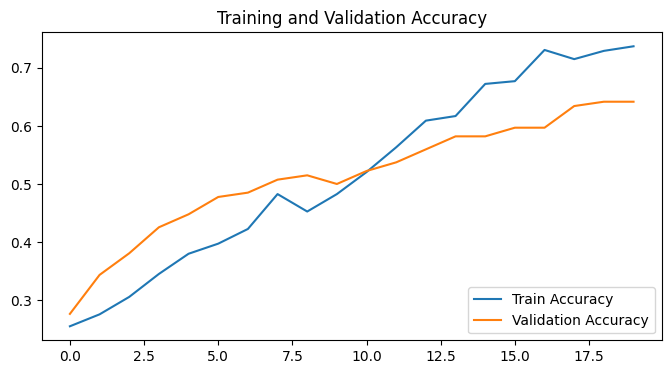

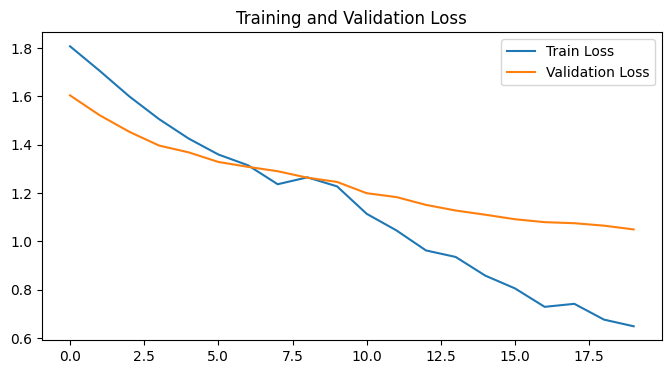

In [ ]:
acc = history.history["accuracy"] + history_fine.history["accuracy"]
val_acc = history.history["val_accuracy"] + history_fine.history["val_accuracy"]

loss = history.history["loss"] + history_fine.history["loss"]
val_loss = history.history["val_loss"] + history_fine.history["val_loss"]

plt.figure(figsize=(8, 4))
plt.plot(acc, label="Train Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Training and Validation Accuracy")
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(loss, label="Train Loss")
plt.plot(val_loss, label="Validation Loss")
plt.legend(loc="upper right")
plt.title("Training and Validation Loss")
plt.show()

##10. Evaluate the model

In [ ]:
test_loss, test_accuracy = model.evaluate(test_dataset)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 29s 6s/step - accuracy: 0.6884 - loss: 0.9595
Test Loss: 0.9595215320587158
Test Accuracy: 0.6884058117866516


In [ ]:
y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

In [ ]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

       angry       0.65      0.61      0.63        36
       happy       0.76      0.86      0.81        37
 melancholic       0.74      0.59      0.65        29
         sad       0.62      0.67      0.64        36

    accuracy                           0.69       138
   macro avg       0.69      0.68      0.68       138
weighted avg       0.69      0.69      0.69       138



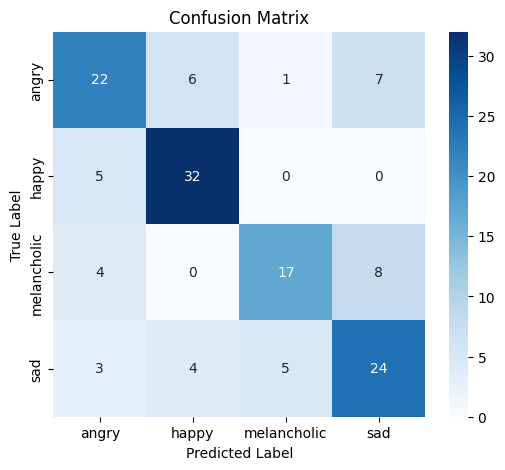

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
model.save("/content/resnet50_four_class_model.keras")
print("Model saved successfully.")

Model saved successfully.


##11. Predict on new images

In [ ]:
def predict_single_image(image_path, model, class_names):
    img = tf.keras.utils.load_img(
        image_path,
        target_size=(IMG_HEIGHT, IMG_WIDTH)
    )
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array, verbose=0)
    pred_index = np.argmax(predictions[0])
    pred_class = class_names[pred_index]
    confidence = float(np.max(predictions[0]))

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f"Predicted: {pred_class}\nConfidence: {confidence:.4f}")
    plt.axis("off")
    plt.show()

    return pred_class, confidence

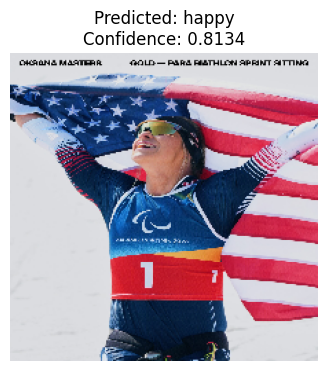

('happy', 0.8134263157844543)

In [ ]:
# Example
sample_image_path = "/content/653541482_18608777929020081_7051260736992456894_n.jpg"
predict_single_image(sample_image_path, model, class_names)